In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

# 1. Veri Setini Yükleme
df = pd.read_csv("data/lip_0_x.csv")

# 2. Eksik Değer Kontrolü
print("Missing values:")
print(df.isnull().sum())
print("-----------------------------")
# 3. İlk 5 Satırı Görüntüle
print(df.head())

Missing values:
time    0
0_x     0
dtype: int64
-----------------------------
   time  0_x
0  0.00  637
1  0.04  638
2  0.08  638
3  0.12  638
4  0.16  638


Gerçek Değerler vs Tahmin Edilen Değerler:
Gerçek: 631, Tahmin: 631.5629280702277
Gerçek: 630, Tahmin: 630.1417459271518
Gerçek: 628, Tahmin: 628.9379849551412
Gerçek: 627, Tahmin: 626.9008934970586
Gerçek: 627, Tahmin: 625.9958655800439
Gerçek: 627, Tahmin: 626.518657099552
Gerçek: 627, Tahmin: 626.9761223501075
Gerçek: 626, Tahmin: 626.95680365
Gerçek: 626, Tahmin: 625.5842337671467
Gerçek: 625, Tahmin: 625.6341087249975
Gerçek: 624, Tahmin: 624.555807471418
Gerçek: 624, Tahmin: 623.5056795983127
Gerçek: 623, Tahmin: 623.6460813614289
Gerçek: 623, Tahmin: 622.7436392480463
Gerçek: 622, Tahmin: 622.867952416441
Gerçek: 622, Tahmin: 621.6883030652627
Gerçek: 622, Tahmin: 621.9069401626722
Gerçek: 622, Tahmin: 622.0011809878248
Gerçek: 620, Tahmin: 622.1773805155366
Gerçek: 620, Tahmin: 619.5340337106696
Gerçek: 619, Tahmin: 619.6160887714816
Gerçek: 620, Tahmin: 618.734999444861
Gerçek: 620, Tahmin: 620.3787536176312
Gerçek: 620, Tahmin: 620.3571741763005
Gerçek: 620, Tahmin: 620.31559

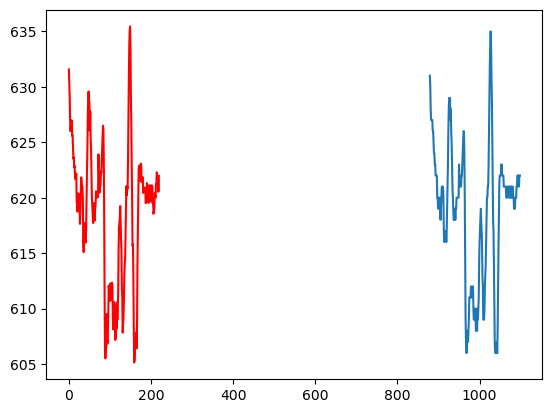

In [8]:
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

# 4. Veri Setini Train ve Test olarak Bölme
train_size = int(len(df) * 0.8)  # %80 eğitim, %20 test
train, test = df['0_x'][:train_size], df['0_x'][train_size:]
history = [x for x in train]
predictions = list()
# walk-forward validation
for t in range(len(test)):
	model = ARIMA(history, order=(5,1,1)) # ARIMA modeli oluşturuluyor (son 5 değer)
	model_fit = model.fit() # Model eğitiliyor
	output = model_fit.forecast()  # Bir sonraki değeri tahmin ediyor
	yhat = output[0] # Tahmin sonucu
	predictions.append(yhat) # Tahmini kaydet
	obs = test.iloc[t] # Gerçek değer
	history.append(obs) # Modeli güncelle (bir sonraki tahmin için)


# evaluate forecasts
# Performans Metriklerini Hesaplama

mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
mape = mean_absolute_percentage_error(test, predictions)

print("Gerçek Değerler vs Tahmin Edilen Değerler:")
for expected, predicted in zip(test, predictions):
    print(f"Gerçek: {expected}, Tahmin: {predicted}")

print("------------------------------------------------------------------------------")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
# plot forecasts against actual outcomes
plt.plot(test)
plt.plot(predictions, color='red')
plt.show()

Gerçek Değerler vs Tahmin Edilen Değerler:
Gerçek: 631, Tahmin: 631.515664048209
Gerçek: 630, Tahmin: 630.1948833664538
Gerçek: 628, Tahmin: 628.9291895307459
Gerçek: 627, Tahmin: 626.8042961684088
Gerçek: 627, Tahmin: 626.0522389640917
Gerçek: 627, Tahmin: 626.5284702975445
Gerçek: 627, Tahmin: 626.9059085848006
Gerçek: 626, Tahmin: 626.9809969523701
Gerçek: 626, Tahmin: 625.5320297533426
Gerçek: 625, Tahmin: 625.5871247759814
Gerçek: 624, Tahmin: 624.6270534499579
Gerçek: 624, Tahmin: 623.5666461571924
Gerçek: 623, Tahmin: 623.65992050499
Gerçek: 623, Tahmin: 622.7194579943592
Gerçek: 622, Tahmin: 622.8607212263013
Gerçek: 622, Tahmin: 621.7061659212136
Gerçek: 622, Tahmin: 621.8502020528019
Gerçek: 622, Tahmin: 622.0292213404849
Gerçek: 620, Tahmin: 622.2039676329308
Gerçek: 620, Tahmin: 619.5205190306316
Gerçek: 619, Tahmin: 619.6075853190245
Gerçek: 620, Tahmin: 618.71462573611
Gerçek: 620, Tahmin: 620.4484034202285
Gerçek: 620, Tahmin: 620.3965139333886
Gerçek: 620, Tahmin: 620.2

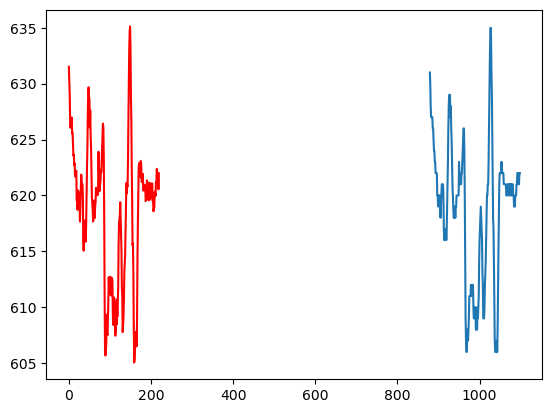

In [10]:
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

# 4. Veri Setini Train ve Test olarak Bölme
train_size = int(len(df) * 0.8)  # %80 eğitim, %20 test
train, test = df['0_x'][:train_size], df['0_x'][train_size:]
history = [x for x in train]
predictions = list()
# walk-forward validation
for t in range(len(test)):
	model = ARIMA(history, order=(10,1,1)) # ARIMA modeli oluşturuluyor (son 10 değer)
	model_fit = model.fit() # Model eğitiliyor
	output = model_fit.forecast()  # Bir sonraki değeri tahmin ediyor
	yhat = output[0] # Tahmin sonucu
	predictions.append(yhat) # Tahmini kaydet
	obs = test.iloc[t] # Gerçek değer
	history.append(obs) # Modeli güncelle (bir sonraki tahmin için)
    
# evaluate forecasts
# Performans Metriklerini Hesaplama

mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
mape = mean_absolute_percentage_error(test, predictions)

print("Gerçek Değerler vs Tahmin Edilen Değerler:")
for expected, predicted in zip(test, predictions):
    print(f"Gerçek: {expected}, Tahmin: {predicted}")

print("------------------------------------------------------------------------------")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
# plot forecasts against actual outcomes
plt.plot(test)
plt.plot(predictions, color='red')
plt.show()

C:\Users\Asus\anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Asus\anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Asus\anaconda3\lib\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Gerçek Değerler vs Tahmin Edilen Değerler:
Gerçek: 631, Tahmin: 631.5982623908803
Gerçek: 630, Tahmin: 630.2121332548813
Gerçek: 628, Tahmin: 629.0136375192562
Gerçek: 627, Tahmin: 626.9833986560885
Gerçek: 627, Tahmin: 626.3075414121884
Gerçek: 627, Tahmin: 626.715377191261
Gerçek: 627, Tahmin: 627.1300064625451
Gerçek: 626, Tahmin: 627.1039006945692
Gerçek: 626, Tahmin: 625.5562562513237
Gerçek: 625, Tahmin: 625.6785444702739
Gerçek: 624, Tahmin: 624.7575923575089
Gerçek: 624, Tahmin: 623.6897966320579
Gerçek: 623, Tahmin: 623.7711715137709
Gerçek: 623, Tahmin: 622.8795318415808
Gerçek: 622, Tahmin: 623.0577686125586
Gerçek: 622, Tahmin: 621.8569518414223
Gerçek: 622, Tahmin: 622.1116692280332
Gerçek: 622, Tahmin: 622.3105200232455
Gerçek: 620, Tahmin: 622.4345495751862
Gerçek: 620, Tahmin: 619.696504643367
Gerçek: 619, Tahmin: 619.7009407402744
Gerçek: 620, Tahmin: 618.6659933050877
Gerçek: 620, Tahmin: 620.4577347766522
Gerçek: 620, Tahmin: 620.435132731371
Gerçek: 620, Tahmin: 620

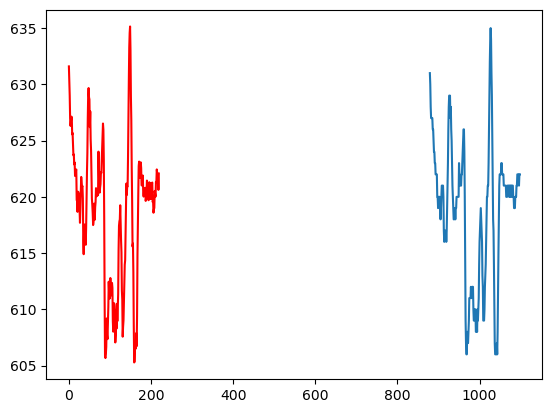

In [11]:
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

# 4. Veri Setini Train ve Test olarak Bölme
train_size = int(len(df) * 0.8)  # %80 eğitim, %20 test
train, test = df['0_x'][:train_size], df['0_x'][train_size:]
history = [x for x in train]
predictions = list()
# walk-forward validation
for t in range(len(test)):
	model = ARIMA(history, order=(20,1,1)) # ARIMA modeli oluşturuluyor (son 20 değer)
	model_fit = model.fit() # Model eğitiliyor
	output = model_fit.forecast()  # Bir sonraki değeri tahmin ediyor
	yhat = output[0] # Tahmin sonucu
	predictions.append(yhat) # Tahmini kaydet
	obs = test.iloc[t] # Gerçek değer
	history.append(obs) # Modeli güncelle (bir sonraki tahmin için)
    
# evaluate forecasts
# Performans Metriklerini Hesaplama

mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
mape = mean_absolute_percentage_error(test, predictions)

print("Gerçek Değerler vs Tahmin Edilen Değerler:")
for expected, predicted in zip(test, predictions):
    print(f"Gerçek: {expected}, Tahmin: {predicted}")

print("------------------------------------------------------------------------------")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
# plot forecasts against actual outcomes
plt.plot(test)
plt.plot(predictions, color='red')
plt.show()

C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: 

Gerçek Değerler vs Tahmin Edilen Değerler:
Gerçek: 631, Tahmin: 10.993743750052252
Gerçek: 630, Tahmin: 10.993743750052252
Gerçek: 628, Tahmin: 10.993743750052252
Gerçek: 627, Tahmin: 10.993743750052252
Gerçek: 627, Tahmin: 10.993743750052252
Gerçek: 627, Tahmin: 10.993743750052252
Gerçek: 627, Tahmin: 10.993743750052252
Gerçek: 626, Tahmin: 10.993743750052252
Gerçek: 626, Tahmin: 10.993743750052252
Gerçek: 625, Tahmin: 10.993743750052252
Gerçek: 624, Tahmin: 10.993743750052252
Gerçek: 624, Tahmin: 10.993743750052252
Gerçek: 623, Tahmin: 10.993743750052252
Gerçek: 623, Tahmin: 10.993743750052252
Gerçek: 622, Tahmin: 10.993743750052252
Gerçek: 622, Tahmin: 10.993743750052252
Gerçek: 622, Tahmin: 10.993743750052252
Gerçek: 622, Tahmin: 10.993743750052252
Gerçek: 620, Tahmin: 10.993743750052252
Gerçek: 620, Tahmin: 10.993743750052252
Gerçek: 619, Tahmin: 10.993743750052252
Gerçek: 620, Tahmin: 10.993743750052252
Gerçek: 620, Tahmin: 10.993743750052252
Gerçek: 620, Tahmin: 10.9937437500522

C:\Users\Gozde\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


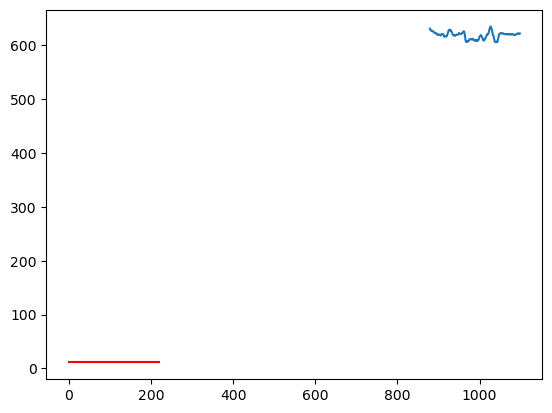

In [7]:
from math import sqrt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

# 4. Veri Setini Train ve Test olarak Bölme
train_size = int(len(df) * 0.8)  # %80 eğitim, %20 test
train, test = df['0_x'][:train_size], df['0_x'][train_size:]
history = [x for x in train]
predictions = list()
input_data = [5,6,7,8,9,10]

# walk-forward validation
for t in range(len(test)):
    #input_data = history[-20:]
    model = ARIMA(input_data, order=(5,1,1)) # ARIMA modeli oluşturuluyor (son 1 değer)
    model_fit = model.fit() # Model eğitiliyor
    output = model_fit.forecast()  # Bir sonraki değeri tahmin ediyor
    yhat = output[0] # Tahmin sonucu
    predictions.append(yhat) # Tahmini kaydet
    obs = test.iloc[t] # Gerçek değer
    history.append(obs) # Modeli güncelle (bir sonraki tahmin için)

# evaluate forecasts
# Performans Metriklerini Hesaplama

mae = mean_absolute_error(test, predictions)
mse = mean_squared_error(test, predictions)
rmse = np.sqrt(mean_squared_error(test, predictions))
mape = mean_absolute_percentage_error(test, predictions)

print("Gerçek Değerler vs Tahmin Edilen Değerler:")
for expected, predicted in zip(test, predictions):
    print(f"Gerçek: {expected}, Tahmin: {predicted}")

print("------------------------------------------------------------------------------")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"Mean Absolute Percentage Error (MAPE): {mape}%")
# plot forecasts against actual outcomes
plt.plot(test)
plt.plot(predictions, color='red')
plt.show()